# Classification of Iris Dataset Using Original Features and LDA

## Objective

The objective of this experiment is to develop and compare two classification pipelines using the Iris dataset:

1. Classification using the original features.
2. Classification using Linear Discriminant Analysis (LDA) for dimensionality reduction before classification.

Two classification algorithms are used in both pipelines:

- Decision Tree Classifier
- AdaBoost Classifier

The performance of the models is compared using accuracy, precision, recall, F1-score, confusion matrix, and training time.

The experiment also evaluates whether LDA can reduce dimensionality while maintaining or improving classification performance and computational efficiency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import time

## 2. Load the Iris Dataset

The Iris dataset is a standard classification dataset available in scikit-learn.


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature names:", feature_names)
print("Target classes:", target_names)

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


## 3. Create a DataFrame

A DataFrame is created to make the dataset easier to inspect and understand.

In [4]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map(
    {0: target_names[0], 1: target_names[1], 2: target_names[2]}
)

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


## 4. Basic Dataset Exploration

Before building the models, the dataset is inspected to understand its structure, class distribution, and feature values.

In [5]:
print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["species"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

Dataset shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 5. Separate Features and Target

The input features are stored in `X`, while the target class is stored in `y`.

The classification task is to predict the Iris species using the four numerical features.

In [6]:
X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


## 6. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is used for testing.
- `stratify=y` maintains approximately the same class distribution in both sets.
- `random_state=42` ensures reproducible results.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


# Pipeline 1 — Classification Using Original Features

In the first pipeline, the four original Iris features are directly provided to the classifiers.

The pipeline is:

Original Features → Classifier → Prediction → Evaluation

Two classifiers are evaluated:

1. Decision Tree
2. AdaBoost

## 7. Decision Tree Using Original Features

A Decision Tree is trained using all four original Iris features.

Decision Trees divide the feature space using decision rules and do not require feature scaling.

In [8]:
start_time = time.perf_counter()

dt_original = DecisionTreeClassifier(
    random_state=42
)

dt_original.fit(X_train, y_train)

dt_original_train_time = time.perf_counter() - start_time

y_pred_dt_original = dt_original.predict(X_test)

print("Decision Tree trained using original features.")
print("Training time:", dt_original_train_time, "seconds")

Decision Tree trained using original features.
Training time: 0.011876800010213628 seconds


## 8. Evaluate Decision Tree — Original Features

In [9]:
dt_original_accuracy = accuracy_score(y_test, y_pred_dt_original)
dt_original_precision = precision_score(
    y_test, y_pred_dt_original, average="weighted"
)
dt_original_recall = recall_score(
    y_test, y_pred_dt_original, average="weighted"
)
dt_original_f1 = f1_score(
    y_test, y_pred_dt_original, average="weighted"
)

print("Decision Tree - Original Features")
print("---------------------------------")
print("Accuracy :", dt_original_accuracy)
print("Precision:", dt_original_precision)
print("Recall   :", dt_original_recall)
print("F1-score :", dt_original_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt_original,
        target_names=target_names
    )
)

Decision Tree - Original Features
---------------------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-score : 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Observation

The Decision Tree achieved **93.33% accuracy**, with precision, recall, and F1-score also at **93.33%**. The confusion matrix shows that all 10 Setosa samples were classified correctly. One Versicolor was misclassified as Virginica and one Virginica as Versicolor, showing that the errors occurred only between these two classes.

## 9. Confusion Matrix — Decision Tree with Original Features

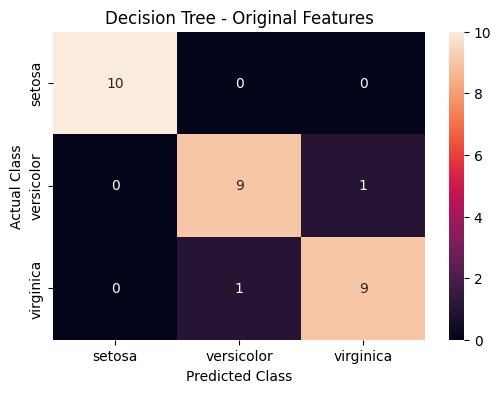

In [10]:
cm = confusion_matrix(y_test, y_pred_dt_original)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree - Original Features")
plt.show()

### Observation – Decision Tree with Original Features

The Decision Tree correctly classified **28 out of 30 test samples**, achieving **93.33% accuracy**. All 10 Setosa samples were classified correctly. One Versicolor was misclassified as Virginica and one Virginica was misclassified as Versicolor, showing that the classification errors occurred only between these two classes.

## 10. AdaBoost Using Original Features

AdaBoost is an ensemble boosting technique.

It combines multiple weak learners sequentially, giving greater attention to samples that were incorrectly classified by previous learners.

The AdaBoost model is trained using the four original Iris features.

In [11]:
start_time = time.perf_counter()

ada_original = AdaBoostClassifier(
    random_state=42
)

ada_original.fit(X_train, y_train)

ada_original_train_time = time.perf_counter() - start_time

y_pred_ada_original = ada_original.predict(X_test)

print("AdaBoost trained using original features.")
print("Training time:", ada_original_train_time, "seconds")

AdaBoost trained using original features.
Training time: 0.3810659000009764 seconds


## 11. Evaluate AdaBoost — Original Features

In [12]:
ada_original_accuracy = accuracy_score(y_test, y_pred_ada_original)
ada_original_precision = precision_score(
    y_test, y_pred_ada_original, average="weighted"
)
ada_original_recall = recall_score(
    y_test, y_pred_ada_original, average="weighted"
)
ada_original_f1 = f1_score(
    y_test, y_pred_ada_original, average="weighted"
)

print("AdaBoost - Original Features")
print("----------------------------")
print("Accuracy :", ada_original_accuracy)
print("Precision:", ada_original_precision)
print("Recall   :", ada_original_recall)
print("F1-score :", ada_original_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_ada_original,
        target_names=target_names
    )
)

AdaBoost - Original Features
----------------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-score : 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 12. Confusion Matrix — AdaBoost with Original Features

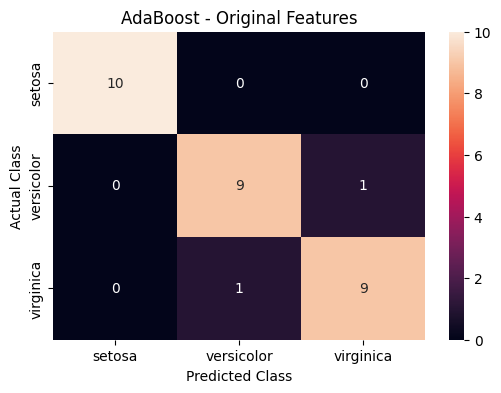

In [13]:
cm = confusion_matrix(y_test, y_pred_ada_original)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("AdaBoost - Original Features")
plt.show()

### Observation – AdaBoost with Original Features

AdaBoost also correctly classified **28 out of 30 test samples**, achieving **93.33% accuracy**. All Setosa samples were classified correctly, while one Versicolor was classified as Virginica and one Virginica as Versicolor. Therefore, AdaBoost produced the **same classification performance as the Decision Tree** when using the original features.

# Pipeline 2 — LDA Dimensionality Reduction + Classification

In the second pipeline, Linear Discriminant Analysis (LDA) is first applied to reduce the dimensionality of the feature space.

The Iris dataset has three classes.

For LDA, the maximum number of discriminant components is:

C - 1

where C is the number of classes.

Therefore:

3 - 1 = 2 components

The pipeline is:

Original Features → LDA → 2 Components → Classifier → Prediction → Evaluation

LDA is supervised dimensionality reduction because it uses the class labels while finding directions that provide good separation between classes.

## 13. Apply LDA

LDA is fitted only on the training data.

This is important because fitting LDA using the complete dataset before the train-test split would allow information from the test set to influence the transformation and cause data leakage.

The trained LDA transformation is then applied separately to the training and testing data.

In [14]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print("Original number of features:", X_train.shape[1])
print("Number of LDA components:", X_train_lda.shape[1])

print("\nLDA training data shape:", X_train_lda.shape)
print("LDA testing data shape:", X_test_lda.shape)

Original number of features: 4
Number of LDA components: 2

LDA training data shape: (120, 2)
LDA testing data shape: (30, 2)


## 14. Visualize the LDA-Reduced Feature Space

The original four-dimensional feature space has been reduced to two LDA components.

These two components can be visualized in a two-dimensional plot.

Because LDA is supervised, the components are selected based on class separation.

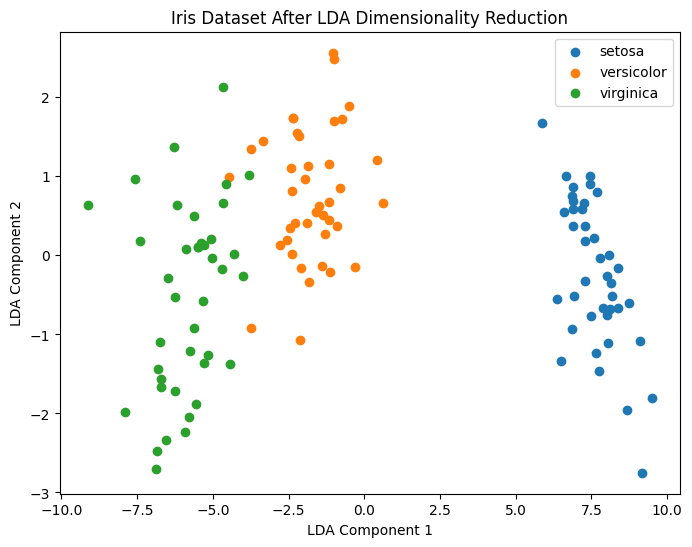

In [15]:
plt.figure(figsize=(8, 6))

for class_value, class_name in enumerate(target_names):
    plt.scatter(
        X_train_lda[y_train == class_value, 0],
        X_train_lda[y_train == class_value, 1],
        label=class_name
    )

plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("Iris Dataset After LDA Dimensionality Reduction")
plt.legend()
plt.show()

### Observation – LDA Dimensionality Reduction

LDA reduced the Iris dataset from **4 original features to 2 components**, giving a **50% reduction in dimensionality**. The plot shows that Setosa forms a clearly separated cluster, while Versicolor and Virginica are also largely separated. This indicates that the two LDA components retain strong information for distinguishing the three classes.

## 15. Decision Tree Using LDA Features

The Decision Tree is now trained using the two LDA components instead of the original four features.

Pipeline:

4 Original Features → LDA → 2 Components → Decision Tree

In [16]:
start_time = time.perf_counter()

dt_lda = DecisionTreeClassifier(
    random_state=42
)

dt_lda.fit(X_train_lda, y_train)

dt_lda_train_time = time.perf_counter() - start_time

y_pred_dt_lda = dt_lda.predict(X_test_lda)

print("Decision Tree trained using LDA features.")
print("Training time:", dt_lda_train_time, "seconds")

Decision Tree trained using LDA features.
Training time: 0.0035330000100657344 seconds


## 16. Evaluate Decision Tree — LDA Features

In [17]:
dt_lda_accuracy = accuracy_score(y_test, y_pred_dt_lda)
dt_lda_precision = precision_score(
    y_test, y_pred_dt_lda, average="weighted"
)
dt_lda_recall = recall_score(
    y_test, y_pred_dt_lda, average="weighted"
)
dt_lda_f1 = f1_score(
    y_test, y_pred_dt_lda, average="weighted"
)

print("Decision Tree - LDA Features")
print("----------------------------")
print("Accuracy :", dt_lda_accuracy)
print("Precision:", dt_lda_precision)
print("Recall   :", dt_lda_recall)
print("F1-score :", dt_lda_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt_lda,
        target_names=target_names
    )
)

Decision Tree - LDA Features
----------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 17. Confusion Matrix — Decision Tree with LDA Features

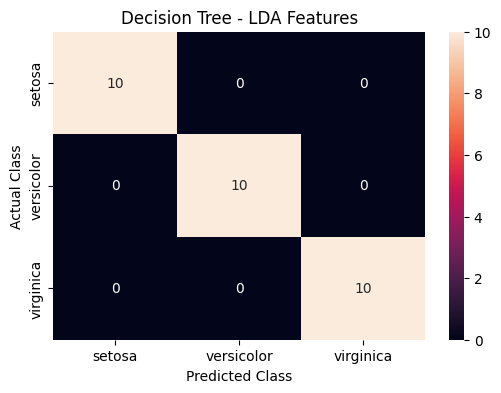

In [18]:
cm = confusion_matrix(y_test, y_pred_dt_lda)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Decision Tree - LDA Features")
plt.show()

### Observation – Decision Tree with LDA Features

After LDA reduction, the Decision Tree correctly classified **all 30 test samples**, achieving **100% accuracy**. The confusion matrix contains **10 correct predictions for each of the three classes and no misclassifications**. Compared with the original-feature model, accuracy increased from **93.33% to 100%**.

## 18. AdaBoost Using LDA Features

AdaBoost is now trained using the two LDA components.

Pipeline:

4 Original Features → LDA → 2 Components → AdaBoost

In [19]:
start_time = time.perf_counter()

ada_lda = AdaBoostClassifier(
    random_state=42
)

ada_lda.fit(X_train_lda, y_train)

ada_lda_train_time = time.perf_counter() - start_time

y_pred_ada_lda = ada_lda.predict(X_test_lda)

print("AdaBoost trained using LDA features.")
print("Training time:", ada_lda_train_time, "seconds")

AdaBoost trained using LDA features.
Training time: 0.18618280001101084 seconds


## 19. Evaluate AdaBoost — LDA Features

In [20]:
ada_lda_accuracy = accuracy_score(y_test, y_pred_ada_lda)
ada_lda_precision = precision_score(
    y_test, y_pred_ada_lda, average="weighted"
)
ada_lda_recall = recall_score(
    y_test, y_pred_ada_lda, average="weighted"
)
ada_lda_f1 = f1_score(
    y_test, y_pred_ada_lda, average="weighted"
)

print("AdaBoost - LDA Features")
print("-----------------------")
print("Accuracy :", ada_lda_accuracy)
print("Precision:", ada_lda_precision)
print("Recall   :", ada_lda_recall)
print("F1-score :", ada_lda_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_ada_lda,
        target_names=target_names
    )
)

AdaBoost - LDA Features
-----------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 20. Confusion Matrix — AdaBoost with LDA Features

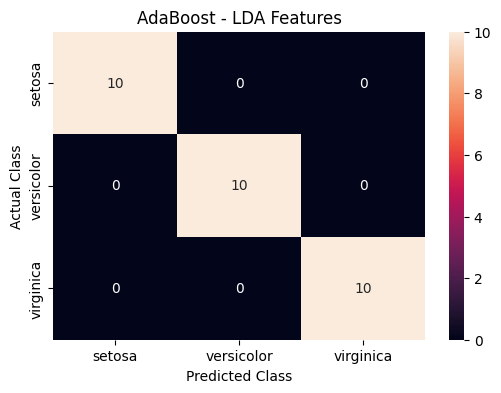

In [21]:
cm = confusion_matrix(y_test, y_pred_ada_lda)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("AdaBoost - LDA Features")
plt.show()

### Observation – AdaBoost with LDA Features

AdaBoost with LDA features also correctly classified **all 30 test samples**, achieving **100% accuracy**. All three classes were classified correctly with no misclassifications. Compared with AdaBoost using the original features, accuracy improved from **93.33% to 100%**.

# 21. Comparison of All Classification Models

The four experiments are now compared:

1. Decision Tree + Original Features
2. AdaBoost + Original Features
3. Decision Tree + LDA Features
4. AdaBoost + LDA Features

The same training and testing data were used for all models to make the comparison consistent.

In [22]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "AdaBoost",
        "Decision Tree",
        "AdaBoost"
    ],
    "Features": [
        "Original (4)",
        "Original (4)",
        "LDA (2)",
        "LDA (2)"
    ],
    "Accuracy": [
        dt_original_accuracy,
        ada_original_accuracy,
        dt_lda_accuracy,
        ada_lda_accuracy
    ],
    "Precision": [
        dt_original_precision,
        ada_original_precision,
        dt_lda_precision,
        ada_lda_precision
    ],
    "Recall": [
        dt_original_recall,
        ada_original_recall,
        dt_lda_recall,
        ada_lda_recall
    ],
    "F1-Score": [
        dt_original_f1,
        ada_original_f1,
        dt_lda_f1,
        ada_lda_f1
    ],
    "Training Time (s)": [
        dt_original_train_time,
        ada_original_train_time,
        dt_lda_train_time,
        ada_lda_train_time
    ]
})

results

,Model,Features,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Decision Tree,Original (4),0.933333,0.933333,0.933333,0.933333,0.011877
1,AdaBoost,Original (4),0.933333,0.933333,0.933333,0.933333,0.381066
2,Decision Tree,LDA (2),1.000000,1.000000,1.000000,1.000000,0.003533
3,AdaBoost,LDA (2),1.000000,1.000000,1.000000,1.000000,0.186183


## 22. Performance Comparison

The following comparison focuses on classification performance.

Higher values of accuracy, precision, recall, and F1-score indicate better classification performance.

The results should be interpreted based on the actual values obtained rather than assuming that LDA will always improve the classifier.

In [23]:
performance_results = results[
    ["Model", "Features", "Accuracy", "Precision", "Recall", "F1-Score"]
]

performance_results

,Model,Features,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,Original (4),0.933333,0.933333,0.933333,0.933333
1,AdaBoost,Original (4),0.933333,0.933333,0.933333,0.933333
2,Decision Tree,LDA (2),1.000000,1.000000,1.000000,1.000000
3,AdaBoost,LDA (2),1.000000,1.000000,1.000000,1.000000


## 23. Training Time Comparison

Training time is compared to examine the computational effect of reducing the number of features from four to two.

Since the Iris dataset is very small, the difference in training time is expected to be small. The main computational advantage of dimensionality reduction becomes more significant for datasets containing many features and large numbers of observations.

In [24]:
time_results = results[
    ["Model", "Features", "Training Time (s)"]
]

time_results

,Model,Features,Training Time (s)
0,Decision Tree,Original (4),0.011877
1,AdaBoost,Original (4),0.381066
2,Decision Tree,LDA (2),0.003533
3,AdaBoost,LDA (2),0.186183


### Observation – Training Time Comparison

LDA also reduced the measured training time. Decision Tree training time decreased from **0.011877 s to 0.003533 s**, a reduction of **70.25%**. AdaBoost training time decreased from **0.381066 s to 0.186183 s**, a reduction of **51.14%**. Therefore, both LDA-based models trained faster in this experiment.

## 24. Accuracy Comparison

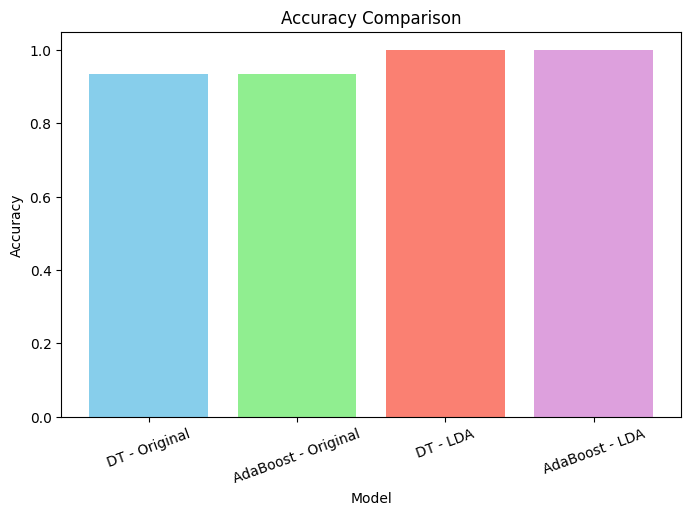

In [26]:
plt.figure(figsize=(8, 5))

labels = [
    "DT - Original",
    "AdaBoost - Original",
    "DT - LDA",
    "AdaBoost - LDA"
]

accuracies = results["Accuracy"]

colors = ["skyblue", "lightgreen", "salmon", "plum"]

plt.bar(labels, accuracies, color=colors)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Accuracy Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()

### Observation – Accuracy Comparison

Both models using the original features achieved **93.33% accuracy**, whereas both LDA-based models achieved **100% accuracy**. Thus, LDA improved the accuracy of both Decision Tree and AdaBoost by **6.67 percentage points** on the test set.

## 25. Feature Dimensionality Comparison

The original dataset contains four features.

After applying LDA, the feature space contains only two components.

Therefore, dimensionality is reduced as follows:

4 features → 2 LDA components

This represents a 50% reduction in the number of feature dimensions.

In [27]:
original_features = X.shape[1]
lda_features = X_train_lda.shape[1]

reduction_percentage = (
    (original_features - lda_features) / original_features
) * 100

print("Original number of features:", original_features)
print("Number of LDA components:", lda_features)
print("Dimensionality reduction:", reduction_percentage, "%")

Original number of features: 4
Number of LDA components: 2
Dimensionality reduction: 50.0 %


# Final Result Summary

The two classification pipelines were compared using Decision Tree and AdaBoost with original features and LDA-reduced features.

LDA reduced the feature space from **4 features to 2 components (50% reduction)**. Both classifiers improved from **93.33% to 100% accuracy**, with precision, recall, and F1-score also reaching 100%.

Training time also decreased:

- **Decision Tree:** 0.011877s → 0.003533s
- **AdaBoost:** 0.381066s → 0.186183s

Therefore, for this Iris dataset, **LDA improved both classification performance and computational efficiency**. However, since Iris is a small, low-dimensional dataset, the computational benefit is limited and may be more significant for larger, high-dimensional datasets.

## Justification for Using LDA

LDA is a supervised dimensionality-reduction technique that uses class labels to maximize separation between classes while reducing within-class variation. It reduced the Iris feature space from **4 to 2 components (50% reduction)**. This improved accuracy from **93.33% to 100% (7.14% relative improvement)** for both Decision Tree and AdaBoost. Training time also decreased by **70.25%** for Decision Tree and **51.14%** for AdaBoost. Thus, LDA provided a more compact and discriminative representation while improving both classification performance and measured computational efficiency in this experiment.